In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 판다스 출력 옵션 설정 (열 많이 보기)
pd.set_option("display.max_columns", 500)

In [2]:
# 장바구니 데이터 불러오기
df = pd.read_csv("../../Data/Groceries_dataset.csv")

# 상위 몇 행으로 데이터 구조 확인
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [3]:
# TransactionID: 고객 번호와 날짜를 합쳐 하나의 거래 ID 생성
df["Member_number"] = df["Member_number"].astype(str)
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

df["TransactionID"] = df["Member_number"] + "-" + df["Date"]

In [4]:
# 데이터 기본 통계 출력
print(f"데이터 기간: {df['Date'].min()} ~ {df['Date'].max()}")
print(f"고유 고객 수: {df['Member_number'].nunique()}명")
print(f"고유 상품 수: {df['itemDescription'].nunique()}개")
print(f"고유 거래 수: {df['TransactionID'].nunique()}건")

데이터 기간: 2014-01-01 ~ 2015-12-30
고유 고객 수: 3898명
고유 상품 수: 167개
고유 거래 수: 14963건


### 탐색적 데이터 분석 (EDA)

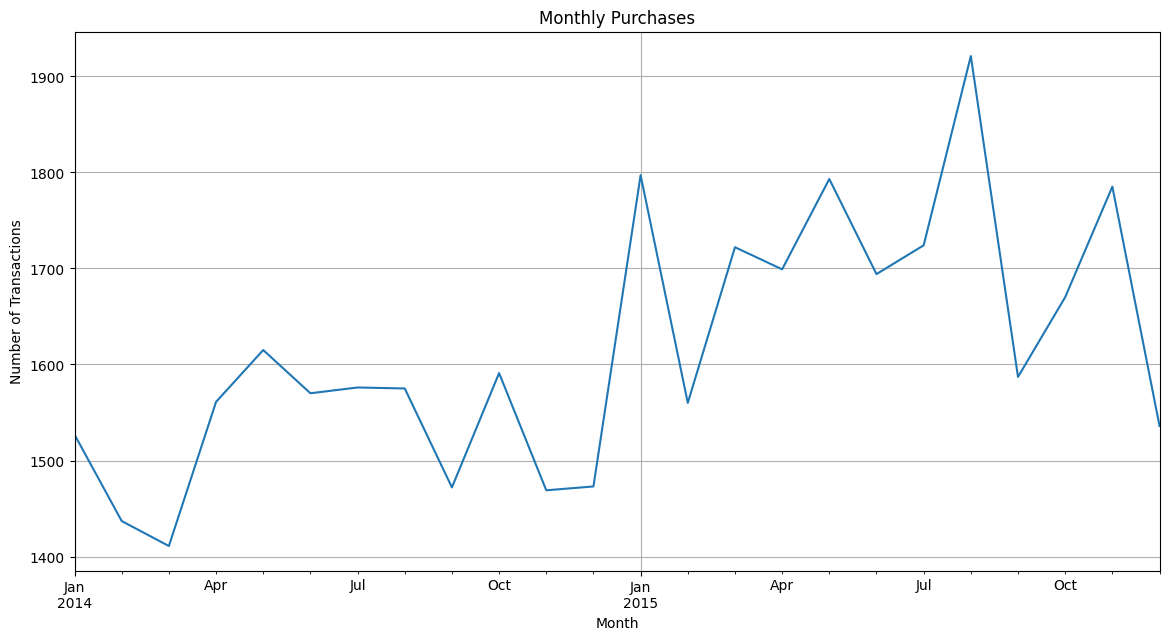

In [5]:
# 월별 거래 수 집계 및 시각화
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_purchases = df.groupby("YearMonth").size()

plt.figure(figsize=(14, 7))
monthly_purchases.plot(kind="line")
plt.title("Monthly Purchases")
plt.ylabel("Number of Transactions")
plt.xlabel("Month")
plt.grid(True)
plt.show()

2015년 1월 초에 거래 수가 크게 증가한 구간이 보인다.  
어떤 상품들이 이 증가를 만들었는지 조금 더 자세히 살펴보자.

In [6]:
# 날짜를 다시 한 번 datetime 형식으로 변환 (안전 차원)
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df["YearMonth"] = df["Date"].dt.to_period("M")

# 월별·상품별 거래 횟수 피벗 테이블 생성
item_monthly_sales = (
    df.groupby(["YearMonth", "itemDescription"])
      .size()
      .unstack()
      .fillna(0)
)

# 관심 있는 기간(2014-12 → 2015-01)의 성장량 계산
start_month = pd.Period("2014-12")
end_month = pd.Period("2015-01")

growth_data = item_monthly_sales.loc[end_month] - item_monthly_sales.loc[start_month]
sorted_growth = growth_data.sort_values(ascending=False)

print("2014-12 → 2015-01 사이 가장 많이 성장한 상위 10개 상품")
sorted_growth.head(10)

2014-12 → 2015-01 사이 가장 많이 성장한 상위 10개 상품


itemDescription
sausage           50.0
tropical fruit    39.0
frankfurter       37.0
whole milk        36.0
citrus fruit      26.0
chicken           25.0
pork              22.0
pip fruit         21.0
yogurt            21.0
canned beer       21.0
dtype: float64

In [7]:
# 전체 기간 기준 상위 15개 판매 상품
top_items = df["itemDescription"].value_counts().nlargest(15)

print("가장 많이 판매된 상위 15개 상품:")
print(top_items)

가장 많이 판매된 상위 15개 상품:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
pastry               785
pip fruit            744
shopping bags        731
canned beer          717
bottled beer         687
Name: count, dtype: int64


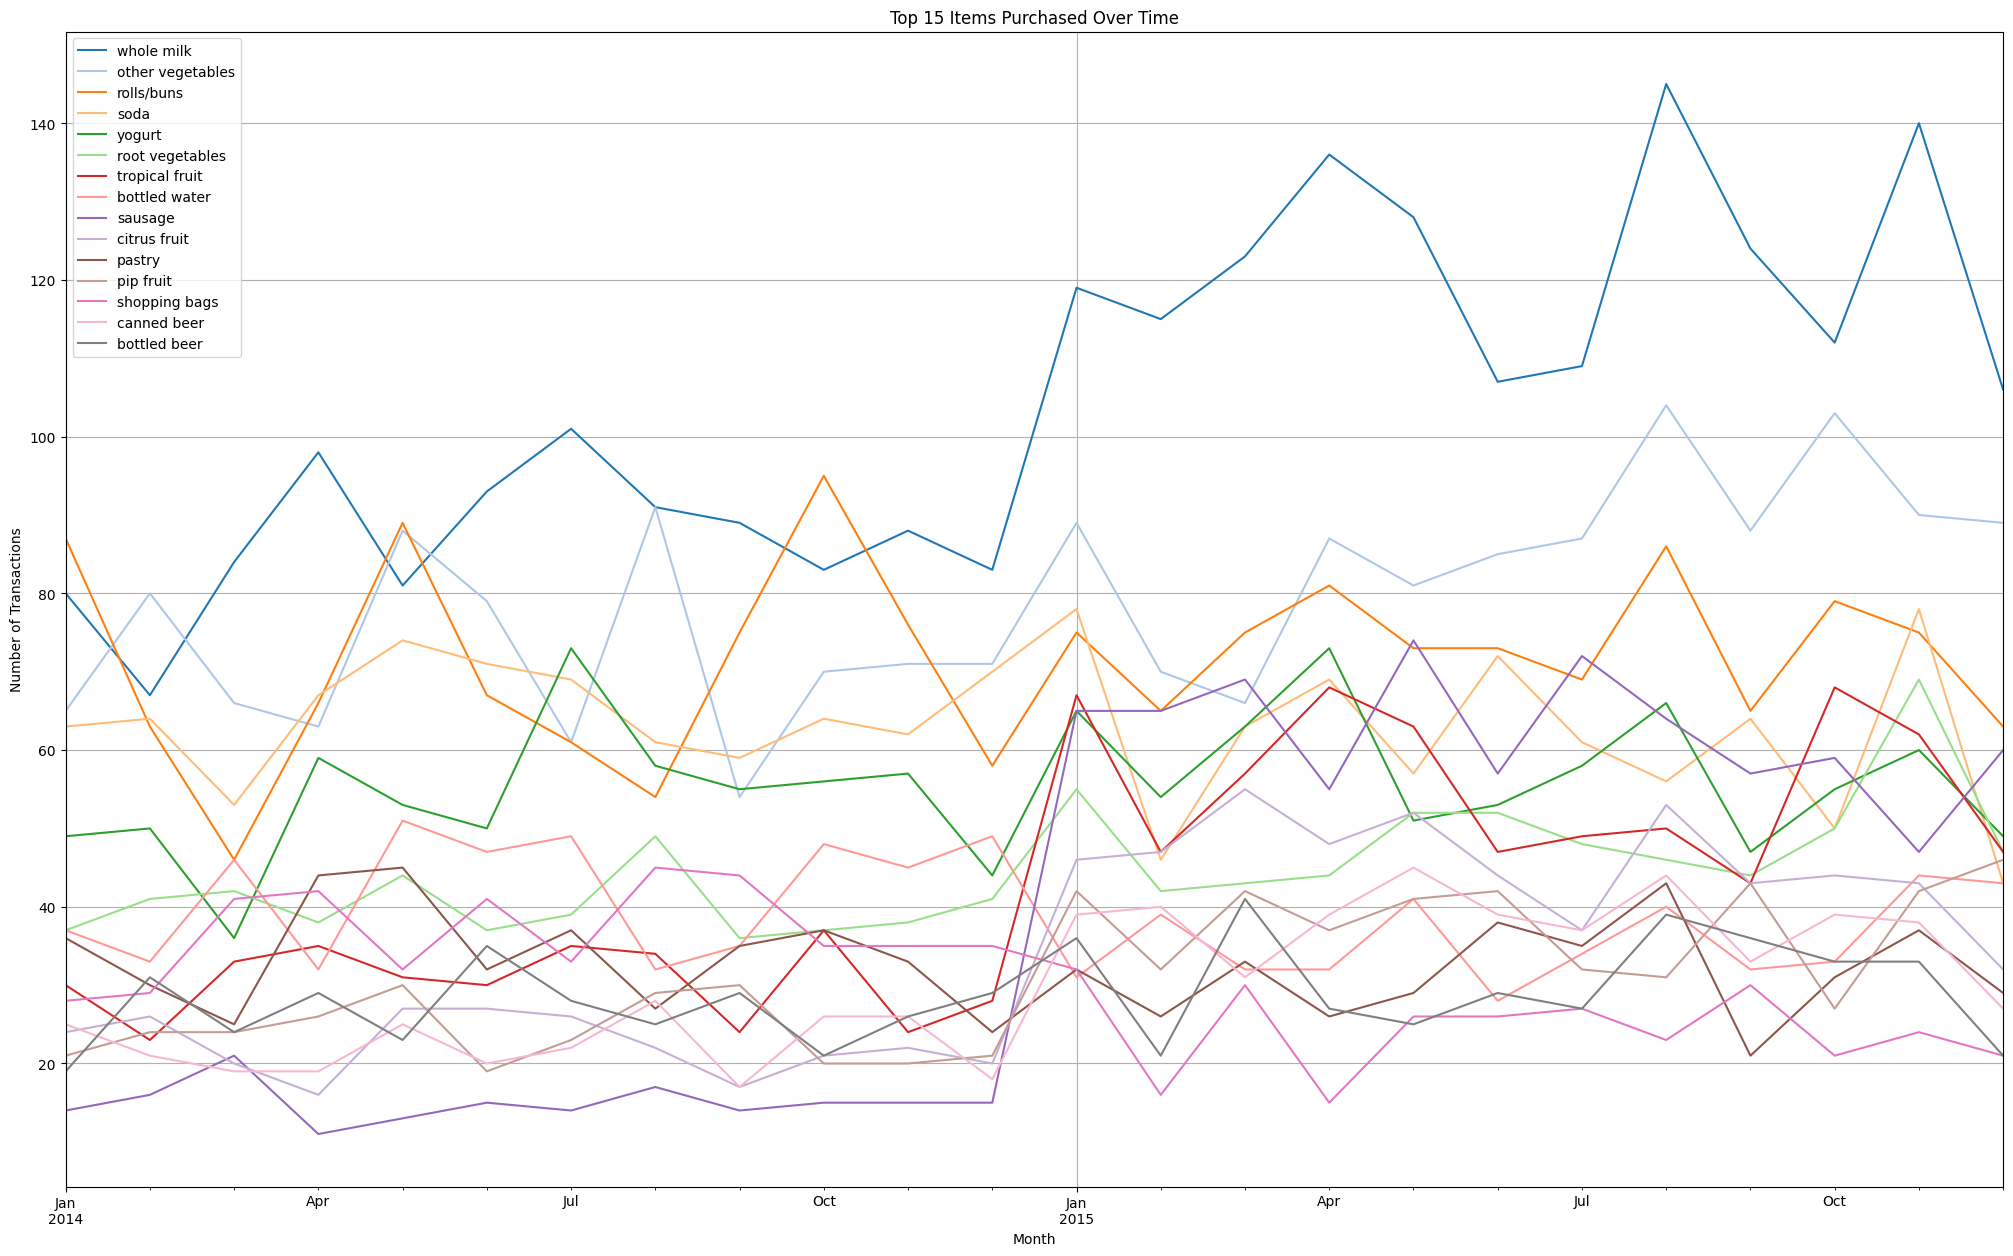

In [8]:
# 상위 15개 인기 상품만 필터링
top_items_over_time = df[df["itemDescription"].isin(top_items.index)]

# 색상 팔레트 (최대 20개 색상)
colors = plt.cm.tab20.colors

plt.figure(figsize=(25, 15))
for idx, item in enumerate(top_items.index):
    monthly_data = (
        top_items_over_time[top_items_over_time["itemDescription"] == item]
        .groupby("YearMonth")
        .size()
    )
    monthly_data.plot(label=item, color=colors[idx])

plt.legend()
plt.title("Top 15 Items Purchased Over Time")
plt.ylabel("Number of Transactions")
plt.xlabel("Month")
plt.grid(True)
plt.show()

In [9]:
# 거래 횟수가 많은 상위 10명 고객
top_customers = (
    df.groupby("Member_number")
      .size()
      .nlargest(10)
      .reset_index(name="Number of Transactions")
)

top_customers

,Member_number,Number of Transactions
0,3180,36
1,2051,33
2,3050,33
3,3737,33
4,2271,31
5,2433,31
6,2625,31
7,3915,31
8,3872,30
9,2394,29


In [10]:
# 거래 1건당 평균 상품 수
avg_items_per_transaction = (
    df.groupby("TransactionID")["itemDescription"].size().mean()
)

print(f"거래 1건당 평균 상품 수: {avg_items_per_transaction:.2f}개")

거래 1건당 평균 상품 수: 2.59개


### Apriori 알고리즘

Apriori 알고리즘은 장바구니 분석에서 자주 등장하는 품목 집합과  
연관 규칙을 찾을 때 널리 사용된다.  

데이터에서 자주 등장하는 단일 품목부터 시작해,  
충분히 자주 나타나는 한 더 큰 아이템 집합으로 확장해 나가는 방식이다.

In [11]:
# 원본 데이터 예시 다시 확인
df.head()

,Member_number,Date,itemDescription,TransactionID,YearMonth
0,1808,2015-07-21,tropical fruit,1808-2015-07-21,2015-07
1,2552,2015-01-05,whole milk,2552-2015-01-05,2015-01
2,2300,2015-09-19,pip fruit,2300-2015-09-19,2015-09
3,1187,2015-12-12,other vegetables,1187-2015-12-12,2015-12
4,3037,2015-02-01,whole milk,3037-2015-02-01,2015-02


In [12]:
# 거래 단위로 상품 목록 리스트 만들기
transactions = (
    df.groupby("TransactionID")["itemDescription"]
      .apply(list)
      .reset_index(name="Items")
)

# TransactionEncoder를 사용해 one-hot 인코딩 수행
te = TransactionEncoder()
te_array = te.fit_transform(transactions["Items"])

# Boolean 행렬을 데이터프레임으로 변환
basket = pd.DataFrame(te_array, columns=te.columns_)

# 거래 ID를 다시 붙여 두기 (추후 분석용)
basket["TransactionID"] = transactions["TransactionID"]

In [13]:
# 거래-상품 행렬 일부 확인
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,cream cheese,curd,curd cheese,decalcifier,dental care,dessert,detergent,dish cleaner,dishes,dog food,domestic eggs,female sanitary products,finished products,fish,flour,flower (seeds),flower soil/fertilizer,frankfurter,frozen chicken,frozen dessert,frozen fish,frozen fruits,frozen meals,frozen potato products,frozen vegetables,fruit/vegetable juice,grapes,hair spray,ham,hamburger meat,hard cheese,herbs,honey,house keeping products,hygiene articles,ice cream,instant coffee,jam,ketchup,kitchen towels,kitchen utensil,light bulbs,liqueur,liquor,liquor (appetizer),liver loaf,long life bakery product,make up remover,male cosmetics,margarine,mayonnaise,meat,meat spreads,misc. beverages,mustard,napkins,newspapers,nut snack,nuts/prunes,oil,onions,organic products,organic sausage,other vegetables,packaged fruit/vegetables,pasta,pastry,pet care,photo/film,pickled vegetables,pip fruit,popcorn,pork,pot plants,potato products,preservation products,processed cheese,prosecco,pudding powder,ready soups,red/blush wine,rice,roll products,rolls/buns,root vegetables,rubbing alcohol,rum,salad dressing,salt,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback,TransactionID
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1000-2014-06-24
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

이제 전처리된 거래-상품 행렬에 Apriori 알고리즘을 적용해  
자주 등장하는 아이템 집합을 찾을 수 있다.

`min_support`는  
**전체 거래 중 해당 아이템 집합이 포함된 비율**을 의미한다.  
값을 너무 크게 잡으면 규칙이 거의 안 나오고,  
너무 작게 잡으면 노이즈 규칙이 많이 나온다.

In [14]:
# Apriori 적용 전에 TransactionID 열 제거 (상품 존재 여부만 사용)
basket_sets = basket.drop(columns=["TransactionID"])

# Apriori 알고리즘으로 자주 등장하는 아이템 집합 추출
frequent_itemsets = apriori(
    basket_sets,
    min_support=0.0075,   # 전체 거래 중 최소 등장 비율
    use_colnames=True,
)

In [15]:
# 발견된 빈발 아이템 집합 확인
frequent_itemsets

,support,itemsets
0,0.021386,(UHT-milk)
1,0.008087,(baking powder)
2,0.033950,(beef)
3,0.021787,(berries)
4,0.016574,(beverages)
...,...,...
81,0.007552,"(whole milk, root vegetables)"
82,0.008955,"(whole milk, sausage)"
83,0.011629,"(whole milk, soda)"
84,0.008220,"(whole milk, tropical fruit)"


In [16]:
# (참고) 가장 빈도가 높은 아이템 집합 상위 5개를 보고 싶을 때 예시
# frequent_itemsets.sort_values("support", ascending=False).head()

In [17]:
# 2개 이상 상품이 함께 등장하는 아이템 집합만 필터링
multi_itemsets = frequent_itemsets[
    frequent_itemsets["itemsets"].apply(lambda x: len(x) > 1)
]

print(multi_itemsets)

     support                        itemsets
74  0.010559  (other vegetables, rolls/buns)
75  0.009691        (other vegetables, soda)
76  0.014837  (other vegetables, whole milk)
77  0.008087      (yogurt, other vegetables)
78  0.008087              (rolls/buns, soda)
79  0.013968        (rolls/buns, whole milk)
80  0.007819            (yogurt, rolls/buns)
81  0.007552   (whole milk, root vegetables)
82  0.008955           (whole milk, sausage)
83  0.011629              (whole milk, soda)
84  0.008220    (whole milk, tropical fruit)
85  0.011161            (yogurt, whole milk)


---

이제 자주 등장하는 아이템 집합으로부터 **연관 규칙**을 생성해 보자.  
`association_rules` 함수에서는 사용할 지표(`metric`)와  
그 지표의 최소 기준값(`min_threshold`)을 지정할 수 있다.

주요 지표들은 다음과 같다.

- **Support**  
  전체 거래 중 해당 아이템(집합)을 포함하는 비율.

- **Confidence**  
  두 아이템 A, B에 대해 "A가 구매되었을 때 B도 함께 구매될 조건부 확률"  
  즉, P(B | A)를 말한다.

- **Lift**  
  "A와 B가 독립일 때 기대되는 동시구매 확률"에 비해  
  실제 동시구매 확률이 얼마나 큰지 나타내는 비율.  
  1보다 크면 두 아이템이 함께 사일 가능성이 높다는 뜻이다.

- **Leverage**  
  실제 동시구매 비율과, 두 아이템이 독립이라고 가정했을 때  
  기대되는 동시구매 비율의 차이. 0이면 두 아이템이 사실상 독립적이다.

In [18]:
# 연관규칙 생성 (metric='lift', 최소 기준값은 필요에 따라 조정 가능)
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=0.001,
)

# 예시: lift와 confidence 기준을 동시에 적용하고 싶을 때
# rules = rules[(rules["lift"] >= 1.0) & (rules["confidence"] >= 0.5)]

In [19]:
# 수치를 소수 둘째 자리까지 반올림
rules = rules.round(2)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(other vegetables),(rolls/buns),0.12,0.11,0.01,0.09,0.79,1.0,-0.0,0.97,-0.24,0.05,-0.03,0.09
1,(rolls/buns),(other vegetables),0.11,0.12,0.01,0.10,0.79,1.0,-0.0,0.97,-0.23,0.05,-0.03,0.09
2,(other vegetables),(soda),0.12,0.10,0.01,0.08,0.82,1.0,-0.0,0.98,-0.20,0.05,-0.02,0.09
3,(soda),(other vegetables),0.10,0.12,0.01,0.10,0.82,1.0,-0.0,0.98,-0.20,0.05,-0.03,0.09
4,(other vegetables),(whole milk),0.12,0.16,0.01,0.12,0.77,1.0,-0.0,0.96,-0.25,0.06,-0.04,0.11
5,(whole milk),(other vegetables),0.16,0.12,0.01,0.09,0.77,1.0,-0.0,0.97,-0.26,0.06,-0.03,0.11
6,(yogurt),(other vegetables),0.09,0.12,0.01,0.09,0.77,1.0,-0.0,0.97,-0.25,0.04,-0.03,0.08
7,(other vegetables),(yogurt),0.12,0.09,0.01,0.07,0.77,1.0,-0.0,0.98,-0.25,0.04,-0.02,0.08
8,(rolls/buns),(soda),0.11,0.10,0.01,0.07,0.76,1.0,-0.0,0.97,-0.27,0.04,-0.03,0.08
9,(soda),(rolls/buns),0.10,0.11,0.01,0.08,0.76,1.0,-0.0,0.97,-0.26,0.04,-0.03,0.08


In [20]:
# frozenset 형태의 선행/결과 아이템을 문자열로 변환 (시각화/해석 편의용)
rules["antecedents"] = rules["antecedents"].apply(lambda x: list(x)[0]).astype(str)
rules["consequents"] = rules["consequents"].apply(lambda x: list(x)[0]).astype(str)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,other vegetables,rolls/buns,0.12,0.11,0.01,0.09,0.79,1.0,-0.0,0.97,-0.24,0.05,-0.03,0.09
1,rolls/buns,other vegetables,0.11,0.12,0.01,0.10,0.79,1.0,-0.0,0.97,-0.23,0.05,-0.03,0.09
2,other vegetables,soda,0.12,0.10,0.01,0.08,0.82,1.0,-0.0,0.98,-0.20,0.05,-0.02,0.09
3,soda,other vegetables,0.10,0.12,0.01,0.10,0.82,1.0,-0.0,0.98,-0.20,0.05,-0.03,0.09
4,other vegetables,whole milk,0.12,0.16,0.01,0.12,0.77,1.0,-0.0,0.96,-0.25,0.06,-0.04,0.11


- **antecedents / consequents**  
  규칙의 왼쪽(조건, A ⇒ B 중 A)과 오른쪽(결과, B)에 해당하는 아이템 집합

- **antecedent support / consequent support**  
  전체 거래 중 선행/결과 아이템 집합이 각각 포함된 비율

- **support**  
  선행과 결과가 **동시에** 포함된 거래의 비율

- **confidence**  
  선행이 발생했을 때 결과가 함께 발생할 조건부 확률  
  (support / antecedent support)

- **lift**  
  선행과 결과가 독립이라고 가정했을 때 기대되는 동시구매 비율과 비교한  
  상대적 증가 정도. 1보다 크면 함께 구매될 가능성이 높다는 의미

- **leverage**  
  실제 동시구매 비율과, 독립 가정 하에서의 기대 비율의 차이.  
  값이 0이면 두 아이템이 독립적이라는 뜻이다.

- **conviction, zhangs_metric**  
  규칙의 유의성을 보는 추가 지표들로, 값이 클수록(또는 절댓값이 클수록)  
  연관성이 강하다고 해석할 수 있다.

### 연관규칙 시각화

In [21]:
# (옵션) support–confidence–lift 관계를 산점도로 보고 싶을 때 예시 코드
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules)
# plt.xlabel("Support")
# plt.ylabel("Confidence")
# plt.title("Support vs Confidence")
# plt.show()

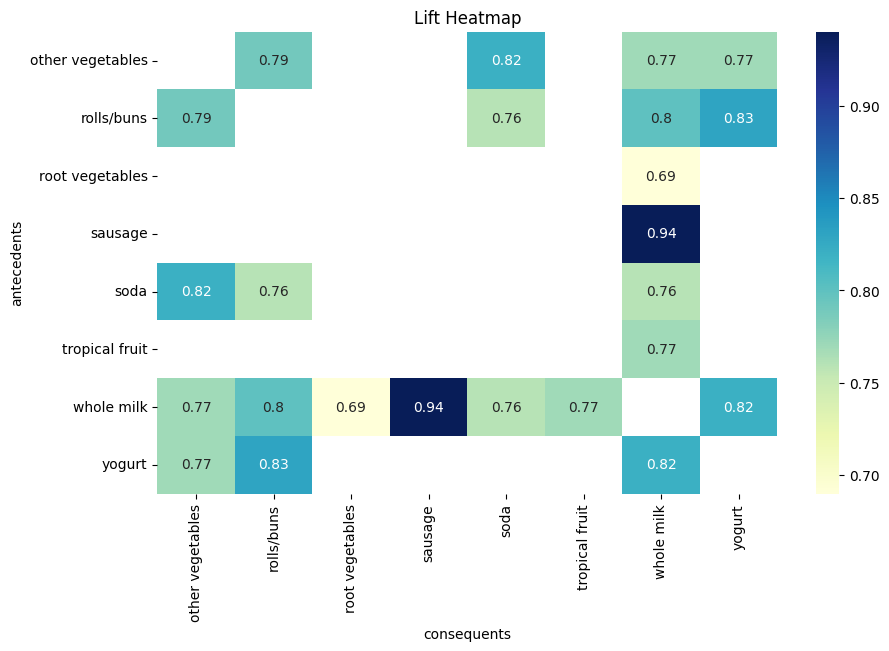

In [22]:
# lift 값을 기준으로 선행 × 결과 상품 매트릭스를 만든 뒤 히트맵으로 시각화
pivot = rules.pivot(index="antecedents", columns="consequents", values="lift")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu")
plt.title("Lift Heatmap")
plt.show()

##### 히트맵 해석

- **Lift 해석**  
  lift > 1이면 선행·결과 상품이 독립일 때보다  
  함께 구매될 가능성이 더 높다는 뜻이고,  
  1보다 작으면 함께 살 가능성이 낮다는 뜻이다.

- **대각선 값**  
  상품 자신과의 조합(자기 자신)은 의미가 없으므로  
  히트맵의 대각선은 비워져 있거나 값이 없다.

- **높은 lift 조합**  
  예를 들어 `yogurt → whole milk`,  
  `root vegetables → sausage`,  
  `rolls/buns → other vegetables` 같은 조합은  
  lift 값이 높아 서로 자주 함께 팔리는 상품이다.

- **중간 수준 lift 조합**  
  `rolls/buns → whole milk`,  
  `other vegetables → whole milk`,  
  `soda → whole milk`,  
  `yogurt → other vegetables` 등은  
  중간 정도의 연관성을 가진다.

- **낮은 lift 조합**  
  `root vegetables → whole milk`처럼 lift 값이 상대적으로 낮은 조합은  
  다른 조합에 비해 함께 구매되는 정도가 크지 않다.

- **색상 해석**  
  색이 진할수록 lift가 높고,  
  즉 두 상품의 연관성이 강한 구간이다.

이런 정보는 진열, 번들 프로모션, 교차 판매 전략을 설계할 때 매우 유용하다.

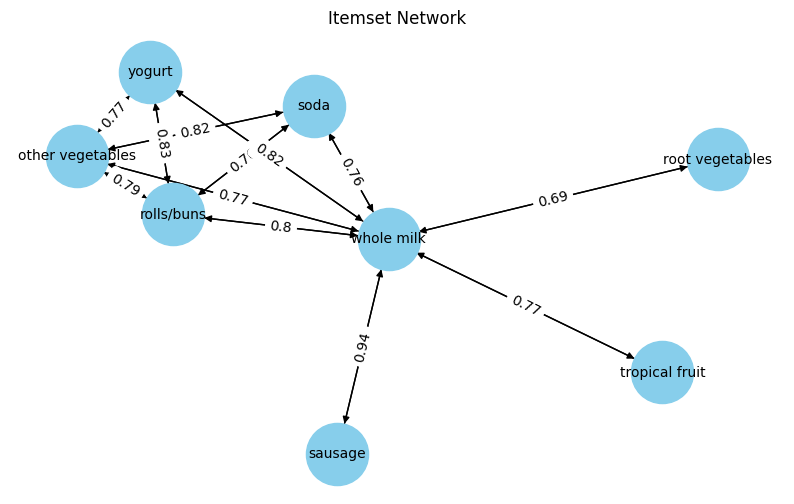

In [23]:
# 연관규칙을 기반으로 방향 그래프(네트워크) 생성
G = nx.from_pandas_edgelist(
    rules,
    source="antecedents",
    target="consequents",
    edge_attr=True,
    create_using=nx.DiGraph(),
)

# 네트워크 시각화를 위한 matplotlib 축 생성
fig, ax = plt.subplots(figsize=(10, 6))

# spring 레이아웃으로 노드 배치 후 그리기
pos = nx.spring_layout(G)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=2000,
    font_size=10,
    ax=ax,
)

edge_labels = nx.get_edge_attributes(G, "lift")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)
ax.set_title("Itemset Network")

plt.show()

이 네트워크 그래프는 연관규칙을 **노드(상품 집합)** 와  
**간선(규칙)** 으로 표현한 것이다. 간선 라벨은 lift 값이다.

- **중심 노드**  
  `frozenset({'whole milk'})`처럼 연결이 많은 노드는  
  여러 상품과 함께 자주 구매되는 핵심 상품을 의미한다.  
  `yogurt`, `other vegetables` 등도 whole milk와 강하게 연결되어 있다.

- **강한 연관**  
  `root vegetables ⇔ sausage`,  
  `rolls/buns ⇔ other vegetables`,  
  `yogurt ⇔ whole milk` 등은 lift가 높아  
  서로 자주 함께 팔리는 조합이다.

- **보통 수준 연관**  
  `rolls/buns ⇔ soda`,  
  `other vegetables ⇔ soda`,  
  `yogurt ⇔ other vegetables` 등은  
  중간 정도의 연관성을 가진다.

- **고립된 노드 없음**  
  모든 노드가 최소 한 번 이상 다른 상품과 연결되어 있어,  
  그래프에 표시된 상품들은 서로 어느 정도 연관성이 있음을 알 수 있다.

요약하면, 이 네트워크는 어떤 상품이 “허브” 역할을 하는지,  
어떤 상품끼리 묶어서 판매 전략을 세우면 좋을지를 한눈에 보여준다.